> _Patch extraction_

In [2]:
import os
import numpy as np
import rasterio
import sys

sys.path.append(os.path.abspath(".."))
sys.path.append(os.path.abspath("../.."))


In [3]:
RASTER_PATH = r"C:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\dataset\raw_images\tifs\scene1\Stack.tif"
OUTPUT_DIR = r"C:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\farmland_detection\dataset\patches_farm\scene1"

os.makedirs(OUTPUT_DIR, exist_ok=True)

PATCH_SIZE = 256
STRIDE = 128 

NORMALIZE = True



In [4]:
from service.patch import extract_patches


In [ ]:
extract_patches(RASTER_PATH,PATCH_SIZE,STRIDE,NORMALIZE,OUTPUT_DIR)


In [20]:
import cv2

PATCH_PATH = r"C:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\farmland_detection\dataset\patches_farm\scene1\patch_00000.npy"
SAVE_DIR = r"C:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\farmland_detection\dataset\patch_pngs\scene1"
os.makedirs(SAVE_DIR, exist_ok=True)

patch = np.load(PATCH_PATH)
print("Patch shape:", patch.shape)

def normalize_band(b):
    return (b - b.min()) / (b.max() - b.min() + 1e-8)

# Handle shape automatically
if patch.shape[0] < 10:  # (C, H, W)
    b2, b3, b4 = patch[0], patch[1], patch[2]
    ndvi = patch[7]
else:  # (H, W, C)
    b2, b3, b4 = patch[:, :, 0], patch[:, :, 1], patch[:, :, 2]
    ndvi = patch[:, :, 7]

# Normalize
b2 = normalize_band(b2)
b3 = normalize_band(b3)
b4 = normalize_band(b4)

rgb = np.stack([b4, b3, b2], axis=-1)
rgb = (rgb * 255).astype(np.uint8)

cv2.imwrite(f"{SAVE_DIR}/patch_rgb.png", cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR))

# NDVI
ndvi = normalize_band(ndvi)
ndvi_img = (ndvi * 255).astype(np.uint8)

cv2.imwrite(f"{SAVE_DIR}/patch_ndvi.png", ndvi_img)

print("Saved correctly!")


Patch shape: (256, 256, 9)
Saved correctly!


> Approach 2

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Load patch
patch = np.load(PATCH_PATH)   # shape (H, W, C)

# ---- Extract bands (adjust if needed) ----
blue  = patch[:, :, 0]  # B02
green = patch[:, :, 1]  # B03
red   = patch[:, :, 2]  # B04
nir   = patch[:, :, 3]  # B08
swir  = patch[:, :, 4]  # B11

# ---- Compute indices ----
ndbi = patch[:, :, 6]  
ndvi = patch[:, :, 7]  
ndwi = patch[:, :, 8]  


# ---- Stack features ----
features = np.stack([red, green, blue, nir, swir, ndvi, ndwi, ndbi], axis=-1)

H, W, C = features.shape
X = features.reshape(-1, C)
X_scaled = scaler.fit_transform(X)


In [22]:
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X_scaled)

segmented = labels.reshape(H, W)


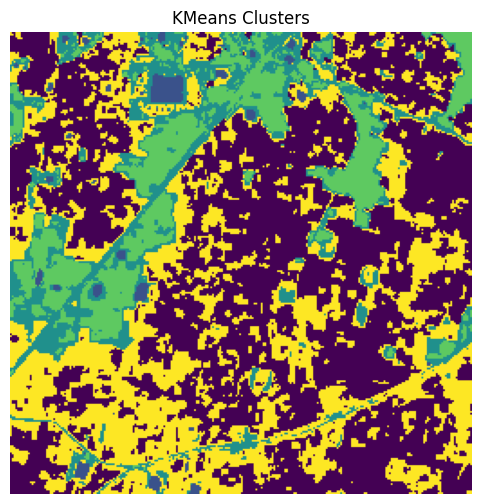

In [23]:
plt.figure(figsize=(6,6))
plt.imshow(segmented, cmap='viridis')
plt.title("KMeans Clusters")
plt.axis('off')
plt.show()


In [24]:
cluster_ndvi_mean = []
cluster_ndbi_mean = []
cluster_ndwi_mean = []


for i in range(5):
    mean_ndvi = ndvi[segmented == i].mean()
    mean_ndbi = ndbi[segmented == i].mean()
    mean_ndwi = ndwi[segmented == i].mean()


    cluster_ndvi_mean.append(mean_ndvi)
    cluster_ndbi_mean.append(mean_ndbi)
    cluster_ndwi_mean.append(mean_ndwi)


    print(f"Cluster {i}: Mean NDVI = {mean_ndvi:.3f}, Mean NDBI = {mean_ndbi:.3f}, Mean NDWI = {mean_ndwi:.3f}")


Cluster 0: Mean NDVI = 0.870, Mean NDBI = 0.182, Mean NDWI = 0.137
Cluster 1: Mean NDVI = 0.305, Mean NDBI = 0.626, Mean NDWI = 0.673
Cluster 2: Mean NDVI = 0.538, Mean NDBI = 0.578, Mean NDWI = 0.366
Cluster 3: Mean NDVI = 0.455, Mean NDBI = 0.686, Mean NDWI = 0.396
Cluster 4: Mean NDVI = 0.755, Mean NDBI = 0.271, Mean NDWI = 0.243


In [25]:
farmland_cluster = np.argmax(cluster_ndvi_mean)
built_up_cluster = np.argmax(cluster_ndbi_mean)
water_cluster = np.argmax(cluster_ndwi_mean)  


print("Farmland cluster:", farmland_cluster)
print("Built-up cluster:", built_up_cluster)
print("Water cluster:", water_cluster)


farmland_mask = segmented == farmland_cluster
rule_built = (ndbi > 0.1)
built_up_mask = (segmented == built_up_cluster)

rule_water = (ndwi > 0)
water_mask = (segmented == water_cluster)


Farmland cluster: 0
Built-up cluster: 3
Water cluster: 1


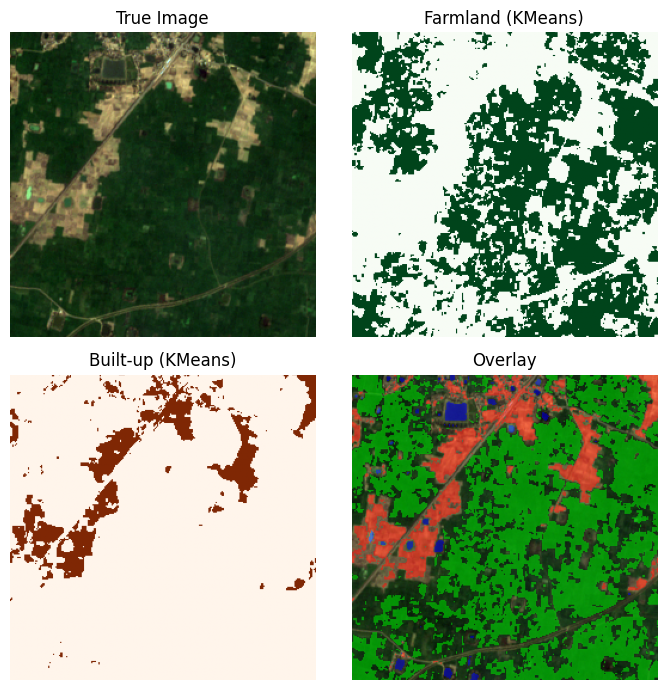

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# True color
rgb = np.stack([red, green, blue], axis=-1)
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-6)

# Overlay
overlay = rgb.copy()
overlay[farmland_mask == 1] = overlay[farmland_mask == 1] * 0.5 + np.array([0,1,0]) * 0.5
overlay[built_up_mask == 1] = overlay[built_up_mask == 1] * 0.5 + np.array([1,0,0]) * 0.5
overlay[water_mask == 1] = overlay[water_mask == 1] * 0.5 + np.array([0,0,1]) * 0.5

# Plot (FIXED → 2x2 grid)
plt.figure(figsize=(7,7))

# Top-left → RGB
plt.subplot(2, 2, 1)
plt.imshow(rgb)
plt.title("True Image")
plt.axis('off')

# Top-right → Farmland
plt.subplot(2, 2, 2)
plt.imshow(farmland_mask, cmap='Greens')
plt.title("Farmland (KMeans)")
plt.axis('off')

# Bottom-left → Built-up
plt.subplot(2, 2, 3)
plt.imshow(built_up_mask, cmap='Oranges')
plt.title("Built-up (KMeans)")
plt.axis('off')

# Bottom-right → Overlay
plt.subplot(2, 2, 4)
plt.imshow(overlay)
plt.title("Overlay")
plt.axis('off')

plt.tight_layout()
plt.show()


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

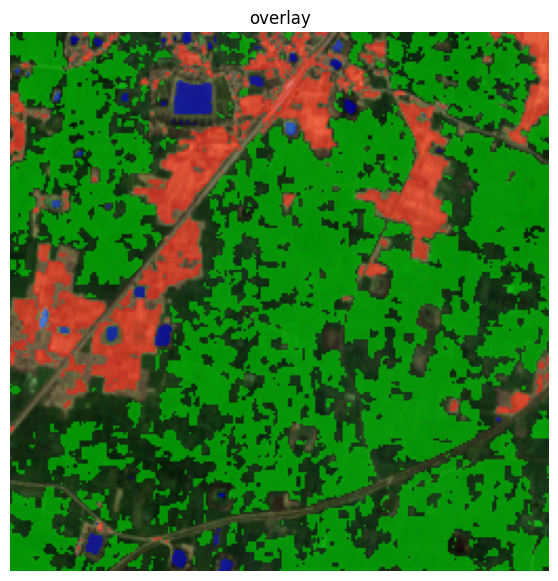

In [28]:
plt.figure(figsize=(7,7))

# Top-left → RGB
plt.imshow(overlay)
plt.title("overlay")
plt.axis('off')
